# 04 — Germany Flows Analysis

**Evaluation: Insight** — What factors drive the net flow (import/export) of power between Germany and its neighbors?

Germany is the central hub. We analyze flows into/out of DE and their drivers.

In [19]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import matplotlib.pyplot as plt
from src.data_loader import load_flows_into, load_spot_price, load_generation_pivot, load_total_load

## Flows into Germany (imports)

Flows into DE (origin -> DE):
['AT->DE', 'BE->DE', 'CH->DE', 'CZ->DE', 'DK1->DE', 'DK2->DE', 'FR->DE', 'NL->DE', 'NO2->DE', 'PL->DE', 'SE4->DE']
At 2024-01-05 12:00:00+00:00: sum of stacked = 4924 MW = total inflow = 4924 MW


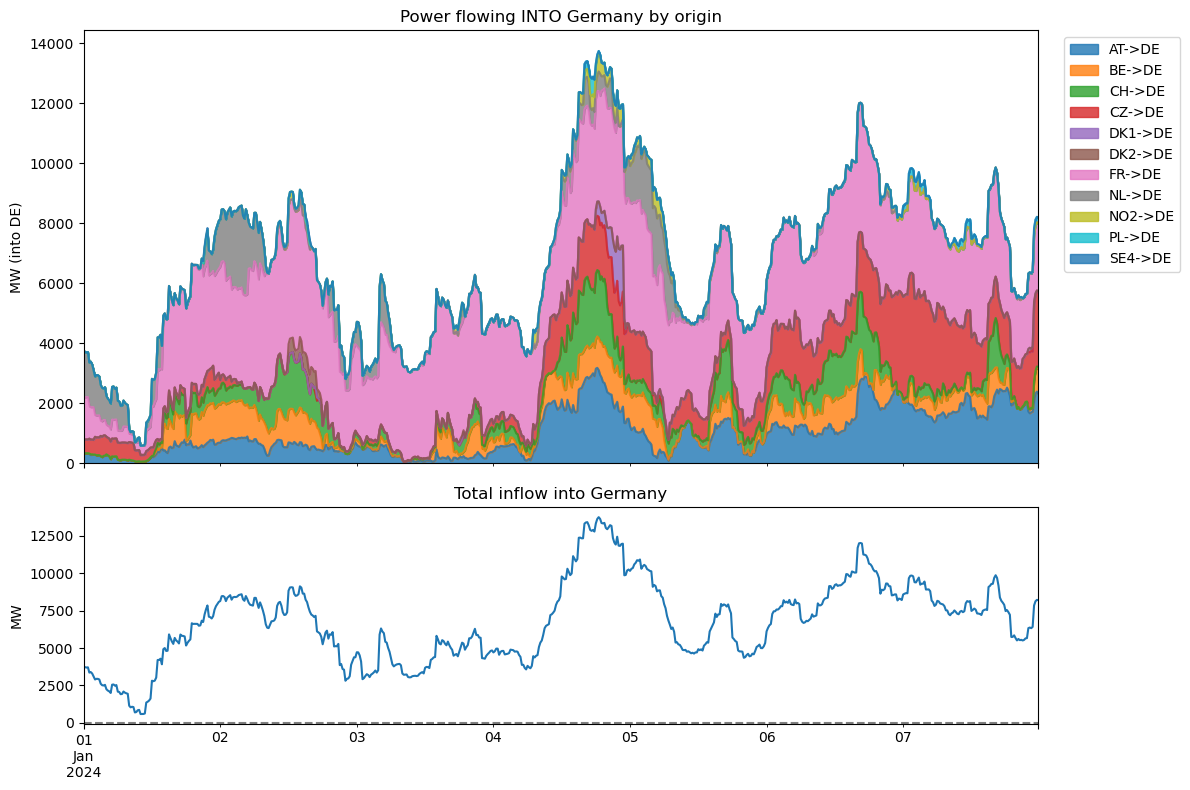

In [29]:
flows_de = load_flows_into("DE")
pivot = flows_de.pivot(index="time", columns="zone", values="value (MW)")
pivot.index = pd.to_datetime(pivot.index, utc=True)

# Reindex to full 15-min grid, then ffill: keeps 15-min samples as-is; expands hourly
# data (FR/SE4) by repeating the value across the 4 quarters.
full_idx = pd.date_range(pivot.index.min(), pivot.index.max(), freq="15min", tz="UTC")
pivot = pivot.reindex(full_idx).ffill()

# Net flow into DE: positive = importing
pivot["net_import"] = pivot.sum(axis=1)

print("Flows into DE (origin -> DE):")
print(pivot.drop(columns=["net_import"]).columns.tolist())

# The stacked values ARE the actual MW per origin. Their sum = total inflow (same as graph below).
zone_cols = [c for c in pivot.columns if c != "net_import"]
ts = pd.Timestamp("2024-01-05 12:00", tz="UTC")
print(f"At {ts}: sum of stacked = {pivot[zone_cols].sum(axis=1).loc[ts]:.0f} MW = total inflow = {pivot['net_import'].loc[ts]:.0f} MW")

sample = pivot.loc["2024-01-01":"2024-01-07"]
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True, height_ratios=[2, 1])
sample.drop(columns=["net_import"]).plot.area(stacked=True, ax=axes[0], alpha=0.8)
axes[0].set_ylabel("MW (into DE)")
axes[0].set_title("Power flowing INTO Germany by origin")
axes[0].legend(bbox_to_anchor=(1.02, 1), loc="upper left")
sample["net_import"].plot(ax=axes[1], color="C0")
axes[1].axhline(0, color="gray", ls="--")
axes[1].set_ylabel("MW")
axes[1].set_title("Total inflow into Germany")
plt.tight_layout()
plt.show()

## Flows out of Germany (exports)

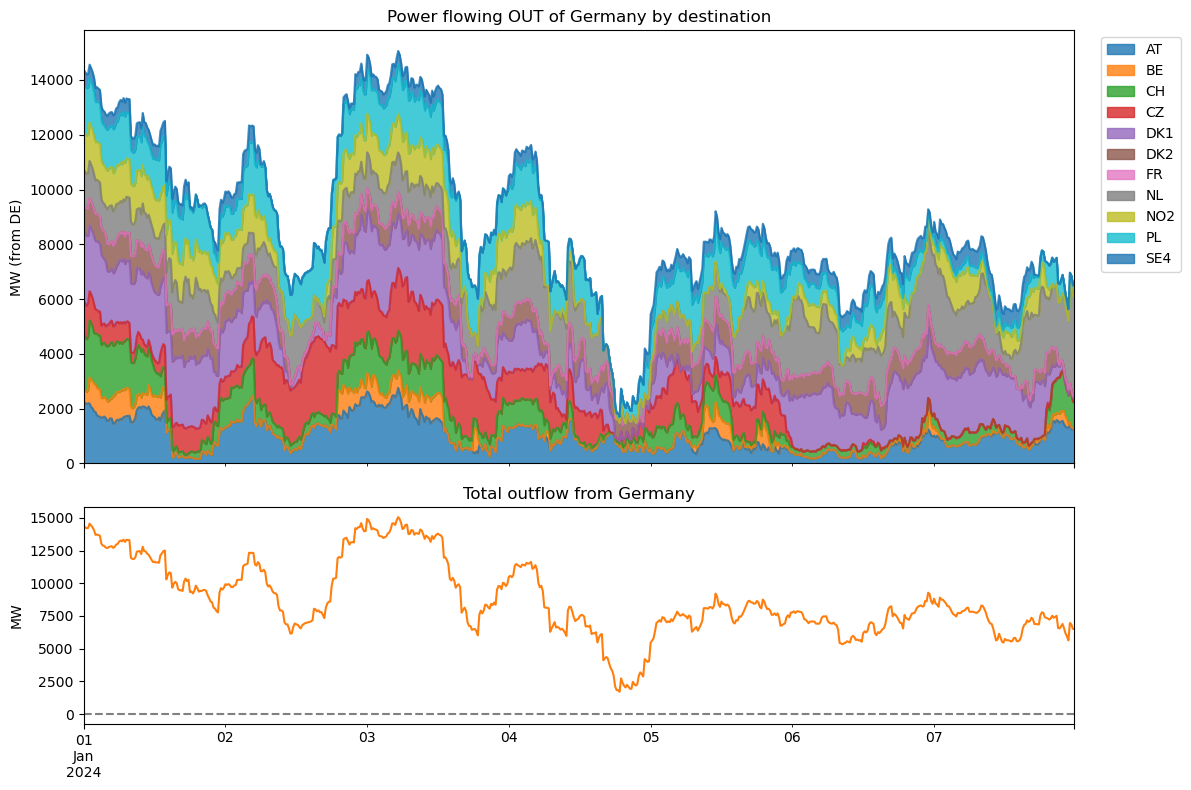

In [30]:
from src.data_loader import load_flows_out_of

flows_out_long = load_flows_out_of("DE")
flows_out = flows_out_long.pivot(index="time", columns="zone", values="value (MW)") if not flows_out_long.empty else pd.DataFrame()
if not flows_out.empty:
    flows_out.index = pd.to_datetime(flows_out.index, utc=True)
    full_idx = pd.date_range(flows_out.index.min(), flows_out.index.max(), freq="15min", tz="UTC")
    flows_out = flows_out.reindex(full_idx).ffill()  # expand hourly to 15-min, keep 15-min as-is
    flows_out["total_export"] = flows_out.sum(axis=1)

if not flows_out.empty:
    sample = flows_out.loc["2024-01-01":"2024-01-07"]
    cols = [c for c in sample.columns if c != "total_export"]
    fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True, height_ratios=[2, 1])
    sample[cols].plot.area(stacked=True, ax=axes[0], alpha=0.8)
    axes[0].set_ylabel("MW (from DE)")
    axes[0].set_title("Power flowing OUT of Germany by destination")
    axes[0].legend(bbox_to_anchor=(1.02, 1), loc="upper left")
    sample["total_export"].plot(ax=axes[1], color="C1")
    axes[1].axhline(0, color="gray", ls="--")
    axes[1].set_ylabel("MW")
    axes[1].set_title("Total outflow from Germany")
    plt.tight_layout()
    plt.show()

## Net flow vs spot price

Correlation: net_import vs DE spot price = 0.568
When DE imports more (scarcity), price tends to rise.


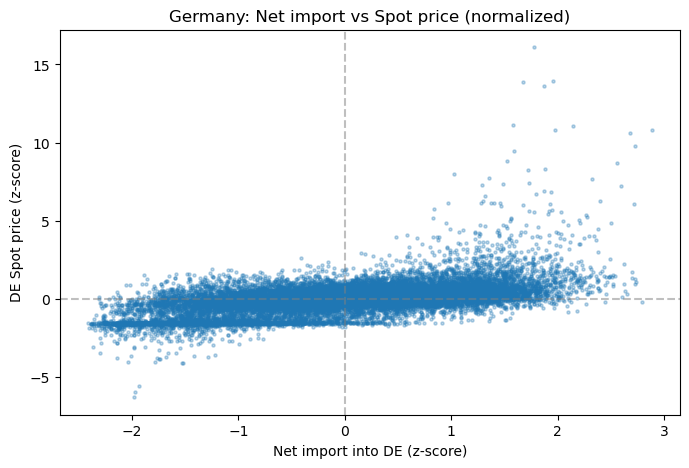

In [32]:
# Align: flows are hourly
net_in = pivot["net_import"].resample("1h").mean()
sp = load_spot_price("DE")
join = sp.join(net_in, how="inner")

corr = join["net_import"].corr(join["price"], method="spearman")
print(f"Correlation: net_import vs DE spot price = {corr:.3f}")
print("When DE imports more (scarcity), price tends to rise.")

# Normalize to z-scores for comparable axes (correlation unchanged)
net_in_norm = (join["net_import"] - join["net_import"].mean()) / join["net_import"].std()
price_norm = (join["price"] - join["price"].mean()) / join["price"].std()

plt.figure(figsize=(8, 5))
plt.scatter(net_in_norm, price_norm, alpha=0.3, s=5)
plt.xlabel("Net import into DE (z-score)")
plt.ylabel("DE Spot price (z-score)")
plt.title("Germany: Net import vs Spot price (normalized)")
plt.axhline(0, color="gray", ls="--", alpha=0.5)
plt.axvline(0, color="gray", ls="--", alpha=0.5)
plt.show()

## Main bilateral flows: France and Czech Republic

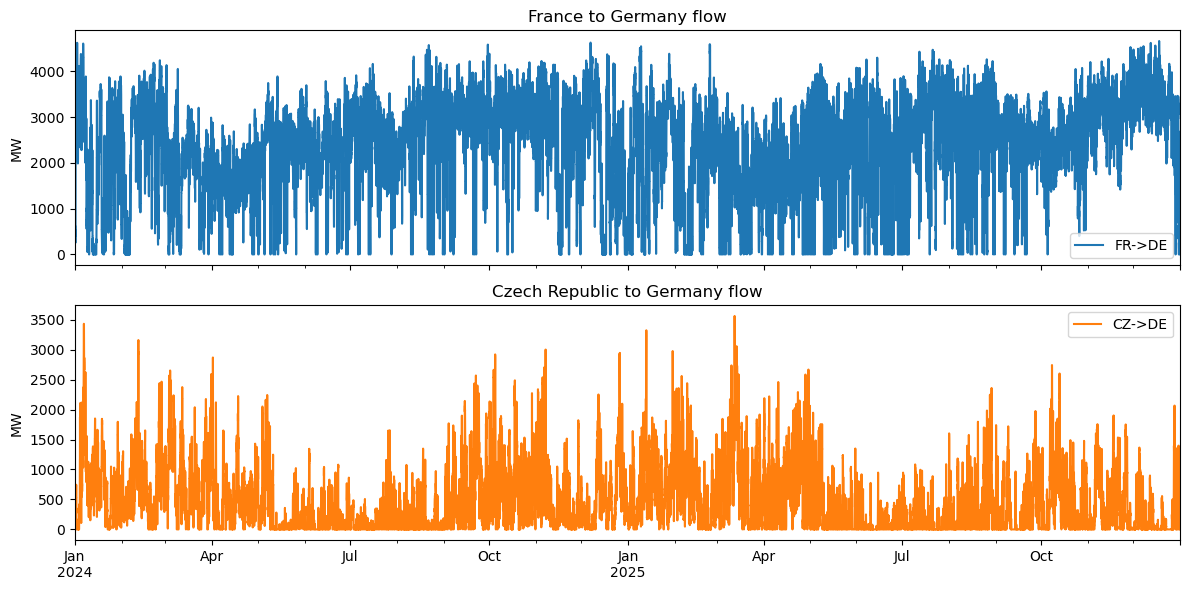

In [33]:
# FR->DE and CZ->DE are often large
fr_de = pivot["FR->DE"] if "FR->DE" in pivot.columns else pd.Series(dtype=float)
cz_de = pivot["CZ->DE"] if "CZ->DE" in pivot.columns else pd.Series(dtype=float)

if not fr_de.empty:
    fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
    fr_de.plot(ax=axes[0], label="FR->DE")
    axes[0].set_ylabel("MW")
    axes[0].set_title("France to Germany flow")
    axes[0].legend()
if not cz_de.empty:
    cz_de.plot(ax=axes[1], label="CZ->DE", color="C1")
    axes[1].set_ylabel("MW")
    axes[1].set_title("Czech Republic to Germany flow")
    axes[1].legend()
    plt.tight_layout()
    plt.show()